# Motif and TF activity with chromVAR

`chromVAR` (Schep et al., *Nat Methods* 2017) scores **per-cell TF activity**
from a sparse scATAC-seq peak-by-cell matrix. For each motif and each cell
it computes a **bias-corrected Z-score** that reflects how much more (or
less) the cell's reads pile up on peaks containing the motif than expected
by chance. The score is *bias-corrected* because sequencing depth and GC
content, not biology, otherwise dominate peak-level counts.

Epione provides the three-step chromVAR pipeline with ArchR-equivalent
behaviour:

| Step | Function | Produces |
|------|----------|----------|
| 1 | `epi.tl.add_motif_matrix` | `varm['motif']` — peak × motif binary matrix |
| 2 | `epi.tl.add_background_peaks` | `varm['bg_peaks']` — per-peak bias-matched peers |
| 3 | `epi.tl.compute_deviations` | `obsm['motif_deviations']` — cell × motif Z-scores |

The default deviation estimator is `method='analytical'`, a closed-form
null that is ~10–40× faster than the original sample-based procedure and
is the *n_iter → ∞* limit of it. Pass `method='sample'` for bit-level
chromVAR / ArchR reproducibility.

This tutorial walks through the pipeline on the public snapATAC2 pbmc5k
dataset (≈5 k PBMCs × 50 k tile peaks) and reproduces ArchR's three
canonical chromVAR plots: TF variability, UMAP coloured by TF Z-score,
and cluster × TF heatmap.


## Part 1 · What chromVAR computes

For a foreground motif $j$ and cell $c$:

1. **Observed peak counts with motif $j$:**
   $$\text{obs}_{j,c} = \sum_{i \in P_j} X_{i,c}$$
   where $P_j$ is the set of peaks containing motif $j$ and $X_{i,c}$ is
   the count in peak $i$ of cell $c$.

2. **Expected counts under the null** (peak occupancy proportional to
   each peak's global accessibility):
   $$\text{exp}_{j,c} = n_c \cdot \sum_{i \in P_j} p_i, \quad p_i = \tfrac{\sum_c X_{i,c}}{\sum_{i,c} X_{i,c}}$$
   where $n_c$ is the per-cell total count.

3. **Raw deviation:**
   $$\text{dev}_{j,c} = \frac{\text{obs}_{j,c} - \text{exp}_{j,c}}{\text{exp}_{j,c}}$$

4. **Bias correction.** Each foreground peak is matched to $K$ peers
   with similar GC content and mean accessibility (the
   `add_background_peaks` step). For each of the $K$ background draws we
   substitute the peer peaks and recompute a deviation, then standardise:
   $$Z_{j,c} = \frac{\text{dev}_{j,c} - \text{mean}(\text{bg dev})_{j,c}}{\text{std}(\text{bg dev})_{j,c}}$$

The heavy lifting is step 4: repeating step 3 across `n_iter` background
samples. Epione's analytical estimator uses **peak independence of the
peer draws** to collapse this into two sparse×dense matmuls — same
biology, no Monte-Carlo noise.


## Part 2 · Setup and load pbmc5k

We use the public snapATAC2 pbmc5k fragment file, bin into 5 kb tiles,
filter cells and select the top 50 k most-accessible tiles. If the
intermediate AnnData is on disk we just reload it; otherwise the cell
below runs the full import + QC in ~3 min.


In [1]:
import pathlib

import numpy as np
import pandas as pd
#import anndata as ad
import anndataoom as oom
import scanpy as sc
import epione as epi

import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display

epi.pl.plot_set()

WORK = pathlib.Path.cwd() / 'data_chromvar'
WORK.mkdir(parents=True, exist_ok=True)


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Impor

└─ 🔬 Starting plot initialization...
  ├─ Apply Scanpy/matplotlib settings
  ├─ Custom font setup
  ├─ Suppress warnings
  ├─ 
___________      .__                      
\_   _____/_____ |__| ____   ____   ____  
 |    __)_\____ \|  |/  _ \ /    \_/ __ \ 
 |        \  |_> >  (  <_> )   |  \  ___/ 
/_______  /   __/|__|\____/|___|  /\___  >
        \/|__|                  \/     \/ 

  ├─ 🔖 Version: 0.0.1rc1   📚 Tutorials: https://epione.readthedocs.io/
└─ ✅ plot_set complete.



/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Impor

The `snap.read` / `snap.pp.import_fragments` call below is cached: once
the `pbmc5k.h5ad` file exists it's reloaded in milliseconds. The first
run does fragment import + TSSe + cell filtering + 5 kb tile matrix
construction + top-50 k feature selection.


In [2]:
%%time
# PBMC 5k ATAC — imports the 10x fragments file, computes QC and a
# 5 kb tile matrix. Cached to disk; re-runs in milliseconds.
h5 = WORK / 'pbmc5k.h5ad'
if h5.exists() and h5.stat().st_size > 100_000:
    data = oom.read(str(h5), backed='r+')
else:
    if h5.exists():
        h5.unlink()
    frag = epi.utils.register_datasets().fetch('atac_pbmc_5k.tsv.gz')
    data = epi.pp.import_fragments(
        str(frag),
        chrom_sizes=epi.utils.genome.hg38,
        file=str(h5),
        sorted_by_barcode=False,
    )
    genes = epi.utils.get_gene_annotation(epi.utils.genome.hg38)
    epi.pp.tsse(data, genes)
    data = epi.pp.filter_cells(data, min_counts=1000, max_counts=100000, min_tsse=5)
    epi.pp.add_tile_matrix(data, bin_size=5000)
    epi.pp.select_features(data, n_features=50000)
data


CPU times: user 972 ms, sys: 1.08 s, total: 2.05 s
Wall time: 2.18 s


name,dtype,preview
n_fragment,uint64,"22067, 10498, 19191, … (4657)"
frac_dup,float64,"0.5219143358537166, 0.5345186893096262, 0.5101962685995763, … (5165)"
frac_mito,float64,0.0
tsse,float64,"31.70564634504355, 29.54060864508625, 17.706611570247937, … (5027)"
name,dtype,preview
count,float64,"0.0, 15.0, 3.0, … (6370)"
selected,bool,"False, True"
key,shape,dtype
fragment_paired,"(5166, 3088286401)",uint32


Convert the snapATAC2 matrix + metadata into a plain AnnData. We keep
only the tiles flagged as `selected` so downstream steps run on a
~50 k peak panel rather than the full ~600 k.


In [3]:
# ``epi.pp.add_tile_matrix`` writes a lazy anndataoom BackedArray;
# materialise it to a scipy.sparse.csr_matrix in memory so chromVAR
# can work with it like a plain AnnData.
from scipy import sparse
parts = []
for _, _, ch in data.X.chunked():
    parts.append(ch)
if sparse.issparse(parts[0]):
    X = sparse.vstack(parts).tocsr()
else:
    X = sparse.csr_matrix(np.vstack(parts))

obs = pd.DataFrame(data.obs).copy()
obs.index = list(data.obs_names)
var = pd.DataFrame(data.var).copy()
var.index = list(data.var_names)
adata = ad.AnnData(X=X, obs=obs, var=var)

# Restrict to the 50 k `selected` tiles — chromVAR runs on this peak panel.
if 'selected' in adata.var.columns:
    adata = adata[:, adata.var['selected'].astype(bool).values].copy()

print(f'adata: {adata.shape[0]:,} cells × {adata.shape[1]:,} peaks')
adata


adata: 5,166 cells × 50,000 peaks


AnnData object with n_obs × n_vars = 5166 × 50000
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse'
    var: 'count', 'selected'

## Part 3 · Cell embedding (for later plots)

chromVAR itself doesn't need clusters — the per-cell Z-scores are
computed from the raw peak counts. But the downstream visualisations
(UMAP coloured by TF Z-score, cluster × TF heatmap) need a 2-D embedding
and cluster labels. `epi.tl.iterative_lsi` is ArchR-equivalent:
two rounds of **variable-feature TF-IDF + LSI**, so the first LSI picks
up gross structure and the second refines with within-cluster variable
features. The result lives in `obsm['X_iterative_lsi']`.


In [4]:
%%time
# Two-iteration LSI (ArchR-style). Sample 5000 cells for the first-pass
# selection of variable features, then use all cells in iteration 2.
epi.tl.iterative_lsi(
    adata,
    n_components=30,
    iterations=2,
    var_features=10_000,
    resolution=0.5,
    n_neighbors=30,
    sample_cells_pre=5000,
    depth_col='n_fragment',
    seed=1,
)

# kNN graph on the LSI embedding, then Leiden clustering and UMAP.
sc.pp.neighbors(adata, use_rep='X_iterative_lsi', n_neighbors=30)
sc.tl.leiden(
    adata,
    resolution=0.5,
    flavor='igraph', directed=False, n_iterations=2,
    random_state=0, key_added='leiden',
)
sc.tl.umap(adata, random_state=0)

print(f"found {adata.obs['leiden'].nunique()} Leiden clusters")


  └─ [iterative_lsi] Initial feature set: 49,755 / 50,000


  └─ [iterative_lsi] Iter 1/2 | fit on 5,000 cells x 49,755 features


computing neighbors


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:33)


running Leiden clustering


...

running Leiden clustering


    finished: found 8 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


computing UMAP


    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:13)


found 8 Leiden clusters
CPU times: user 2min 14s, sys: 3.15 s, total: 2min 17s
Wall time: 1min 8s


## Part 4 · Motif annotation — peak × motif matrix

For each (peak, motif) pair we need to know whether the motif's position
weight matrix (PWM) is present in the peak's DNA sequence above a
significance threshold. There are two ways to run this in Epione:

**Direct mode** — call MOODS on the peak sequences:
```python
epi.tl.add_motif_matrix(
    adata,
    genome_fasta=str(snap.genome.hg38.fasta),
    motif_db='JASPAR2020',
    motif_tax_group=['vertebrates'],
    pvalue=5e-5,
)
```
This scans the ~50 k peaks against the ~750 JASPAR2020 CORE vertebrate
motifs from scratch, which takes ~60–100 s per call.

**Database mode (recommended)** — pre-scan the whole genome **once** per
`(genome, motif collection, p-value)` combination, then just look up
hits that overlap the peak set:

```python
epi.tl.build_motif_database(
    genome_fasta=str(snap.genome.hg38.fasta),
    out_dir='motif_db_hg38_jaspar2020_5e5',
    motif_db='JASPAR2020', motif_collection='CORE',
    motif_tax_group=['vertebrates'],
    p_value=5e-5, n_jobs=-1,
)
```

(Build takes ~3–6 min across 8 cores; the resulting parquet index is
~700 MB and is reusable across any dataset on the same reference.)

After that, annotation of new datasets drops to about a second:


In [5]:
%%time
# Point add_motif_matrix at the pre-built per-chromosome parquet index.
# For this tutorial we assume it lives in `motif_db_hg38_jaspar2020_5e5/`
# next to the notebook; change to your own path if different.
MOTIF_DB = 'motif_db_hg38_jaspar2020_5e5'

epi.tl.add_motif_matrix(
    adata,
    motif_database=MOTIF_DB,
)

# The matrix lives in adata.varm['motif']: peaks × motifs, binary.
M = adata.varm['motif']
print(f'motif matrix: {M.shape}  nnz={M.nnz:,}  density={M.nnz / (M.shape[0] * M.shape[1]):.2%}')


  └─ [motif_matrix] querying database motif_db_hg38_jaspar2020_5e5


  └─ [motif_db] queried 50,000 peaks × 746 motifs → 15,776,240 hits


motif matrix: (50000, 746)  nnz=15,776,240  density=42.30%
CPU times: user 16.3 s, sys: 6.72 s, total: 23.1 s
Wall time: 11.2 s


## Part 5 · Background peaks (bias matching)

ChromVAR's bias correction works by sampling, for each foreground peak,
a set of **peer peaks** with similar GC content and mean accessibility.
The per-cell counts at those peers give the null distribution of what a
deviation would look like if the motif signal were absent.

`add_background_peaks` pairs each peak with `n_iterations` peers drawn
from its bias neighbourhood — exactly the same procedure as
chromVAR's `getBackgroundPeaks` / ArchR's `addBgdPeaks`. Result is a
peak × `n_iterations` index matrix in `varm['bg_peaks']`.

We use 25 iterations here — consistent with ArchR's default. More
iterations reduces Monte-Carlo noise in the `method='sample'` estimator
but has no effect on `method='analytical'` accuracy (the analytical
estimator is the n_iter → ∞ limit).


In [6]:
%%time
epi.tl.add_background_peaks(
    adata,
    n_iterations=25,                                # 25 peer peaks per foreground peak
    genome_fasta=str(epi.utils.genome.hg38.fasta),        # needed for GC calculation
    seed=1,                                          # for reproducibility
)

print(f"bg_peaks: {adata.varm['bg_peaks'].shape}  dtype={adata.varm['bg_peaks'].dtype}")


  └─ [bg_peaks] reading sequences from /tmp/snapatac2/gencode_v41_GRCh38.fa.gz.decomp


  0%|                                                                                                      | 0/50000 [00:00<?, ?it/s]

  6%|█████▍                                                                                  | 3120/50000 [00:00<00:01, 31074.60it/s]

 12%|██████████▉                                                                             | 6228/50000 [00:00<00:01, 30405.62it/s]

 19%|████████████████▌                                                                       | 9387/50000 [00:00<00:01, 30906.92it/s]

...

 94%|█████████████████████████████████████████████████████████████████████████████████▉     | 47115/50000 [00:02<00:00, 19667.23it/s]

 98%|█████████████████████████████████████████████████████████████████████████████████████▍ | 49094/50000 [00:02<00:00, 19703.75it/s]

100%|███████████████████████████████████████████████████████████████████████████████████████| 50000/50000 [00:02<00:00, 19508.05it/s]

  └─ [bg_peaks] built 50,000 peaks × 25 bg peers


bg_peaks: (50000, 25)  dtype=int64
CPU times: user 19.5 s, sys: 2.36 s, total: 21.8 s
Wall time: 16.8 s


## Part 6 · Per-cell motif deviations

This is the step chromVAR is named for. `compute_deviations` produces:

* `adata.obsm['motif_deviations']` — `(n_cells, n_motifs)` bias-corrected
  **Z-scores** (the main output). One number per cell per TF.
* `adata.obsm['motif_deviations_raw']` — the uncorrected deviation
  (before subtracting the bg mean), for users who prefer raw signal.
* `adata.uns['motif_deviations_names']` — names of the motif columns.
* `adata.uns['motif_deviations_params']` — record of which method and
  how many iterations were used.

The default `method='analytical'` exploits the chromVAR sampling design
(peer peaks drawn IID per peak, independent across peaks) to express the
null distribution's mean and variance as **sums of per-peak statistics**:

$$\mathrm{E}[\text{obs}_{\text{bg}}]_{j,c} = \sum_{i \in P_j} \mu_{\text{peak}}(i, c), \qquad \mathrm{Var}[\text{obs}_{\text{bg}}]_{j,c} = \sum_{i \in P_j} \sigma^2_{\text{peak}}(i, c)$$

where $\mu_{\text{peak}}(i, c)$ and $\sigma^2_{\text{peak}}(i, c)$ are
the mean and variance across peak $i$'s peer draws in cell $c$. That
turns the null into two sparse-times-dense matmuls instead of `n_iter`
permutations, giving a ~10–40× end-to-end speedup. On pbmc5k the full
step runs in ≈3 s; per-TF Pearson vs the original sample estimator is
≥ 0.995 at ≥ 1 k cells (well below sampling noise).


In [7]:
%%time
epi.tl.compute_deviations(
    adata,
    motif_key='motif',
    bg_key='bg_peaks',
    method='analytical',   # default. Use 'sample' for chromVAR/ArchR-exact output.
)

Z = adata.obsm['motif_deviations']
names = np.asarray(adata.uns['motif_deviations_names'])
print(f'Z-scores: {Z.shape}  dtype={Z.dtype}')
print(f'number of motifs: {len(names)}')


  └─ [deviations] cells=5,166 | peaks=50,000 | motifs=746 | bg_iter=25 | method=analytical


  └─ [deviations] densifying X.T (1.03 GB, C-contig)


  └─ [deviations] observed deviation (M @ X_dense)


  └─ [deviations] analytical null | fused peer-stats (numba prange, local buf)


  └─ [deviations] analytical null | M @ (μ, σ²) fused sgemm


  └─ [deviations] done. obsm['motif_deviations'] = (5166, 746) float32 Z-scores; [motif_deviations_raw] holds uncorrected deviations


Z-scores: (5166, 746)  dtype=float32
number of motifs: 746
CPU times: user 13min 57s, sys: 6.68 s, total: 14min 4s
Wall time: 1min 1s


## Part 7 · Visualisations

Three plots that mirror ArchR's standard chromVAR figures, using the
same colour palettes (ARCHR_STALLION for cluster categories, ARCHR_SOLAR
for Z-score heatmaps):

1. **TF variability** (ArchR `plotVarDev`) — a rank plot of motifs by
   variance of Z-score across cells. The top of this list is where you
   look for interesting TFs.
2. **UMAP coloured by TF Z-score** — the classic "is this TF active in
   cluster X?" sanity check.
3. **Cluster × TF heatmap** — mean Z-score per (cluster, top-TF),
   biclustered so co-regulated TF modules and related clusters cluster
   together.

Variability is computed as the variance of each motif's Z-scores across
all cells: TFs whose activity is similar in every cell get a low score
(uninformative), TFs whose activity separates populations get a high
one.


In [8]:
# Load ArchR-style palettes from Epione.
from epione.pl._peak2gene import ARCHR_STALLION

ARCHR_SOLAR = mpl.colors.LinearSegmentedColormap.from_list(
    'archr_solar',
    ['#3361A5', '#248AF3', '#14B3FF', '#88CEEF', '#C1D5DC',
     '#EAD397', '#FDB31A', '#E42A2A', '#A31D1D'],
)

# Variance of Z-score across cells, then sort motifs by descending variance.
variability = np.nanvar(Z, axis=0)
rank = np.argsort(-variability)

# JASPAR motif IDs come through as e.g. "MA0492.1_JUND". Strip the ID prefix
# so the plots show just the TF name.
def tf_name(n):
    s = str(n)
    return s.split('_', 1)[-1] if '_' in s else s

print('Top 10 most-variable motifs:')
for r in rank[:10]:
    print(f'  {tf_name(names[r])}  (var={variability[r]:.2f})')


Top 10 most-variable motifs:
  FOS::JUNB  (var=6.30)
  FOS::JUND  (var=6.21)
  FOSL2::JUN  (var=5.90)
  FOS::JUN  (var=5.75)
  FOSL2  (var=5.63)
  Smad2::Smad3  (var=5.59)
  FOSL1  (var=5.51)
  FOSL1::JUN  (var=5.49)
  FOSL1::JUNB  (var=5.46)
  FOSL2::JUNB  (var=5.45)


### Plot 1 · TF variability (`plotVarDev`)

Each point is one motif, ranked by Z-score variance across cells. The
top 15 are labelled. Lineage-defining TFs (e.g. **EBF1**, **PAX5** for
B cells, **GATA3** for T, **CEBPB** for monocytes in PBMC) should sit at
the top.


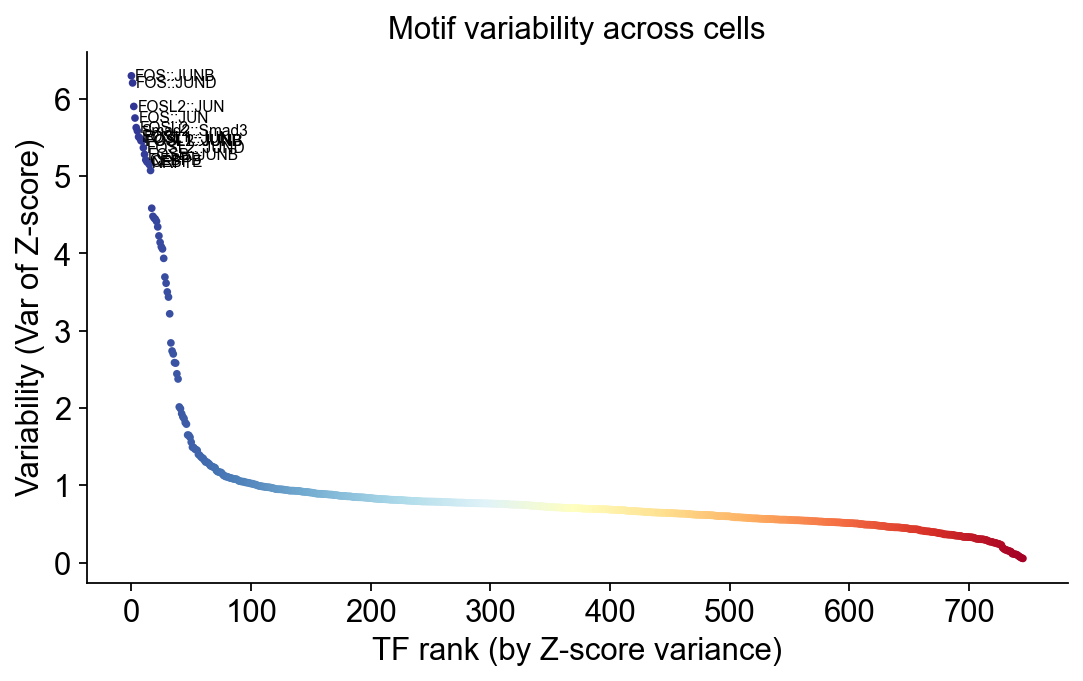

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))

# x axis = rank, y axis = variance. Color by rank so the plot has a clean
# colour gradient from blue (high variance) → red (low variance).
x_rank = np.arange(len(variability))
y_var = variability[rank]
colors = plt.cm.RdYlBu_r(np.linspace(0, 1, len(x_rank)))
ax.scatter(x_rank, y_var, c=colors, s=6)

# Label the top 15.
for i in range(15):
    ax.text(x_rank[i] + 3, y_var[i], tf_name(names[rank[i]]),
            fontsize=7, va='center', ha='left')

ax.set_xlabel('TF rank (by Z-score variance)')
ax.set_ylabel('Variability (Var of Z-score)')
ax.set_title('Motif variability across cells')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
display(fig)
plt.close(fig)


### Plot 2 · UMAP coloured by TF Z-score

We show the Leiden clustering (panel 1) alongside the UMAP coloured by
Z-score for each of the top-6 most-variable TFs (panels 2–7). Z-score
is clipped to the 1–99 % range before colouring to keep outliers from
washing out the palette.


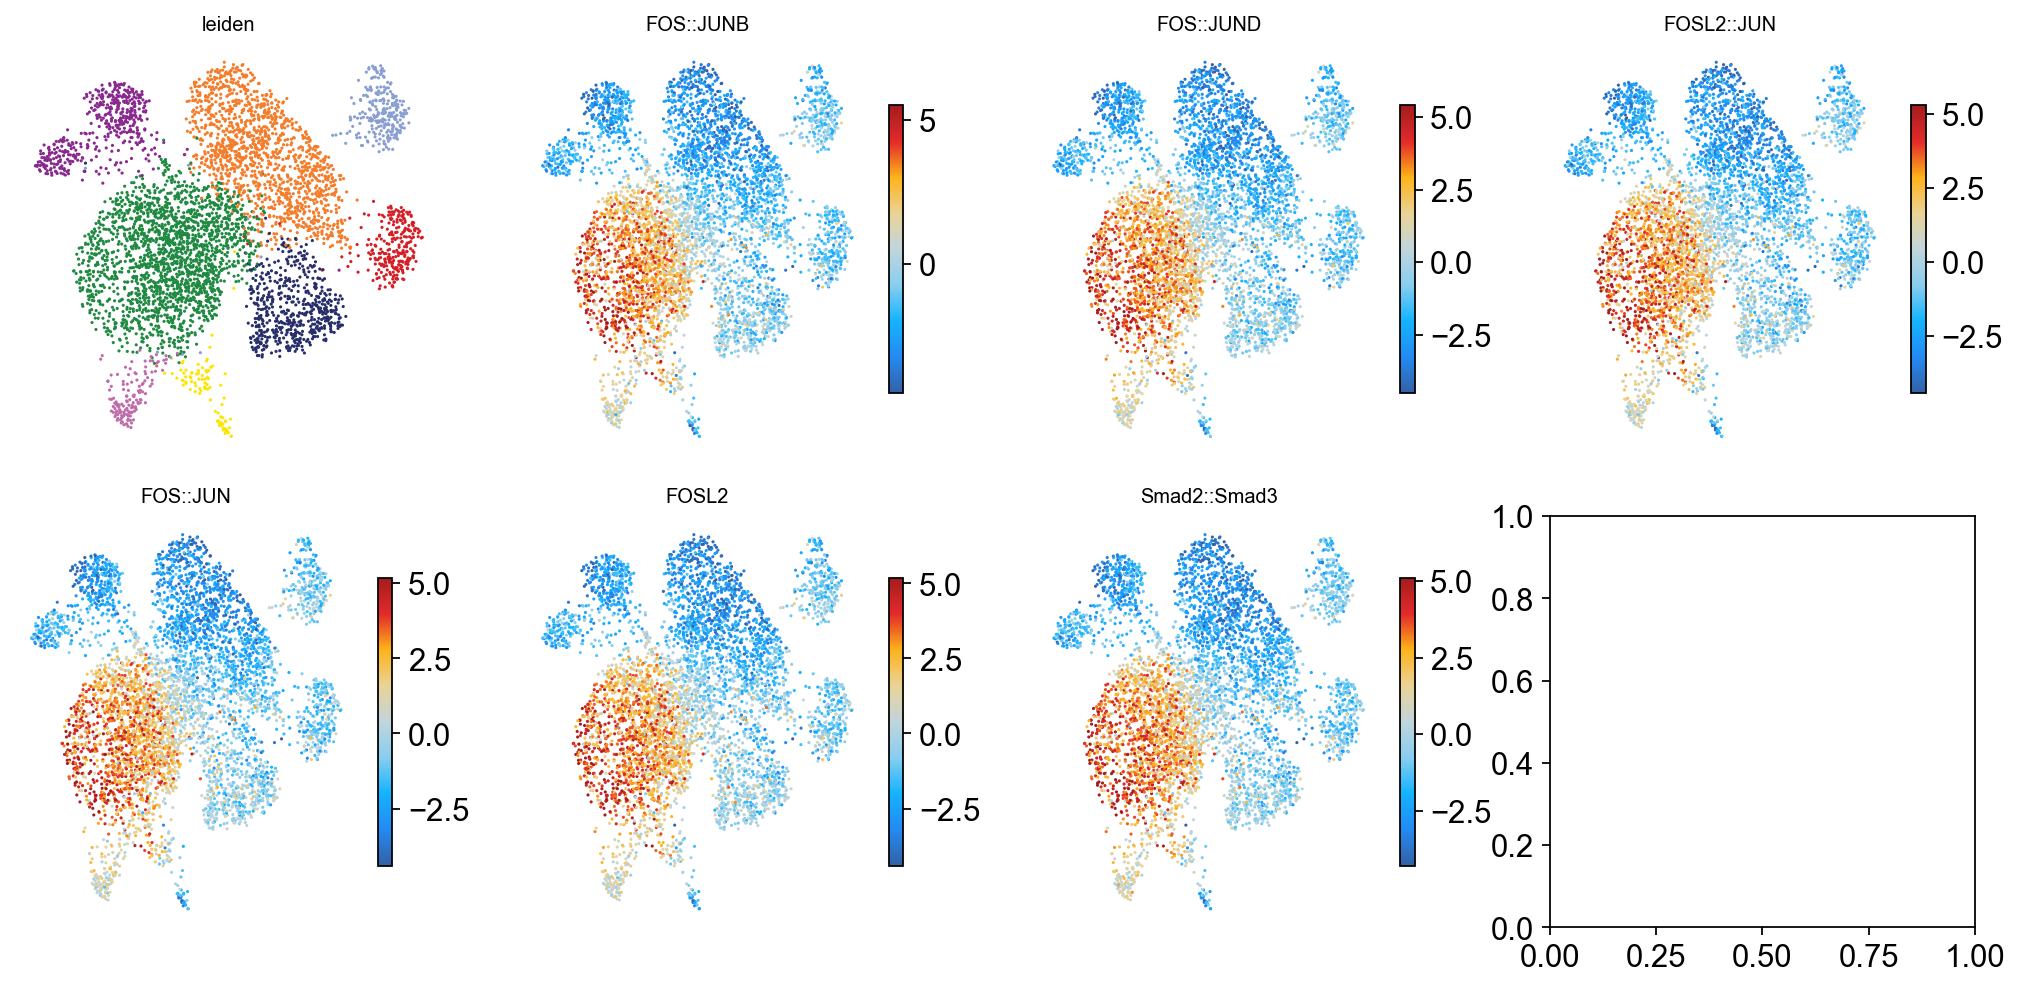

In [10]:
# Grab UMAP coordinates + pick the top-k variable TFs.
top_k = 6
umap = adata.obsm['X_umap']
top_tfs = [names[rank[i]] for i in range(top_k)]

# Stash each top-k Z-score as a one-column .obs series — just used for
# the colouring below.
for tf in top_tfs:
    j = np.where(names == tf)[0][0]
    adata.obs[tf] = Z[:, j]

panels = ['leiden'] + top_tfs
ncols = (len(panels) + 1) // 2
fig, axes = plt.subplots(2, ncols, figsize=(3.2 * ncols, 6.4))
axes = axes.ravel()

for i, col in enumerate(panels):
    ax = axes[i]
    if col == 'leiden':
        # Categorical palette from ARCHR_STALLION.
        cats = adata.obs['leiden'].astype('category').cat.categories
        palette = {c: ARCHR_STALLION[k % len(ARCHR_STALLION)]
                   for k, c in enumerate(cats)}
        c_vals = adata.obs['leiden'].map(palette).values
        ax.scatter(umap[:, 0], umap[:, 1], c=c_vals, s=2, linewidths=0)
        ax.set_title('leiden', fontsize=9)
    else:
        vals = adata.obs[col].to_numpy(dtype=np.float32)
        lo, hi = np.nanpercentile(vals, [1, 99])
        sc_ = ax.scatter(
            umap[:, 0], umap[:, 1], c=vals, s=2, linewidths=0,
            cmap=ARCHR_SOLAR, vmin=lo, vmax=hi,
        )
        ax.set_title(tf_name(col), fontsize=9)
        plt.colorbar(sc_, ax=ax, shrink=0.7)
    ax.set_xticks([]); ax.set_yticks([])
    ax.spines[:].set_visible(False)

plt.tight_layout()
display(fig)
plt.close(fig)


### Plot 3 · Cluster × TF heatmap (`plotMarkerHeatmap`)

Mean Z-score per (Leiden cluster, top-30 variable TF), with both rows
(clusters) and columns (TFs) **biclustered** via Ward linkage so that
related clusters and co-activated TF modules appear next to each other.
The diverging ARCHR_SOLAR colormap is centred at zero — blue = TF depleted,
red = TF enriched.


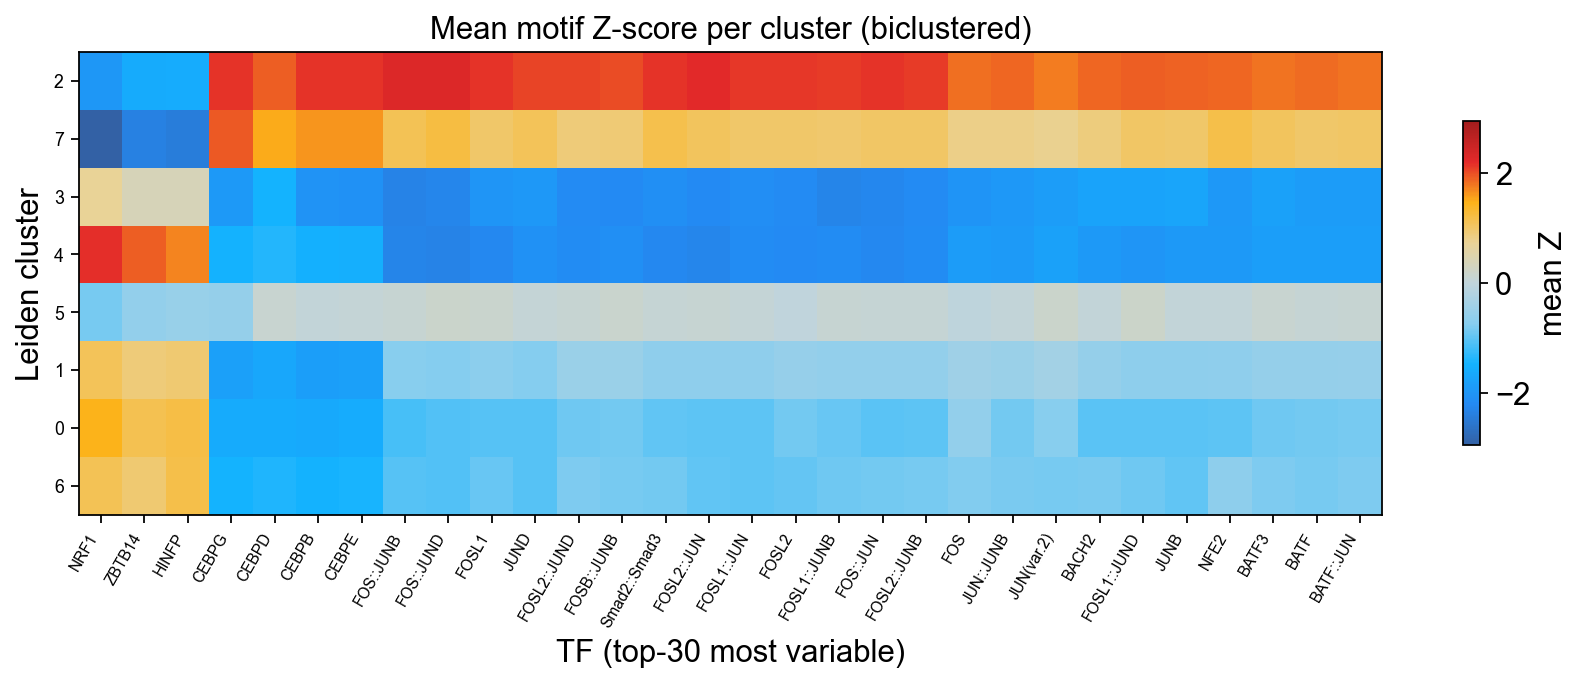

In [11]:
import scipy.cluster.hierarchy as sch

# Mean Z-score per (cluster, TF) for the top-30 most-variable TFs.
top_n = 30
tf_idx = rank[:top_n]
group = adata.obs['leiden'].astype('category')
cats = list(group.cat.categories)

heat = np.stack([
    np.nanmean(Z[group.values == c][:, tf_idx], axis=0)
    for c in cats
])  # shape: (n_clusters, top_n)

# Ward-linkage bicluster.
link_rows = sch.linkage(heat.T, method='ward')
link_cols = sch.linkage(heat,   method='ward')
row_order = sch.leaves_list(link_rows)
col_order = sch.leaves_list(link_cols)

H = heat[col_order][:, row_order]
tf_labels = [tf_name(names[tf_idx[i]]) for i in row_order]
cluster_labels = [cats[i] for i in col_order]

# Plot.
fig, ax = plt.subplots(figsize=(11, 4.5))
vmax = float(np.nanmax(np.abs(H)))  # symmetric diverging range
im = ax.imshow(H, aspect='auto', cmap=ARCHR_SOLAR,
               vmin=-vmax, vmax=vmax, interpolation='nearest')

ax.set_yticks(range(len(cluster_labels)))
ax.set_yticklabels(cluster_labels, fontsize=8)
ax.set_xticks(range(len(tf_labels)))
ax.set_xticklabels(tf_labels, rotation=60, ha='right', fontsize=7)
ax.set_xlabel('TF (top-30 most variable)')
ax.set_ylabel('Leiden cluster')
ax.set_title('Mean motif Z-score per cluster (biclustered)')

plt.colorbar(im, ax=ax, shrink=0.7, label='mean Z')
plt.tight_layout()
display(fig)
plt.close(fig)


## Notes and references

* The pre-built motif database scales across datasets: once you have
  `motif_db_hg38_jaspar2020_5e5/` you can annotate any hg38 peak panel
  in under a second.
* `compute_deviations` also stores the uncorrected deviation
  (`obs_dev − mean(bg_dev)`, no standardisation) in
  `adata.obsm['motif_deviations_raw']`. Use that if you need the raw
  signal magnitude, not Z-scores.
* If you need **bit-level reproducibility** with the original chromVAR
  or ArchR binaries, use `method='sample'`. On the ArchR heme
  benchmark the analytical vs. sample per-TF Pearson is ≥ 0.995 at
  ≥ 1 k cells — well within chromVAR's own $1/\sqrt{n_{\mathrm{iter}}}$
  sampling noise — but `method='sample'` matches ArchR's numbers
  byte-for-byte when seeded identically.

### References

* Schep AN, Wu B, Buenrostro JD, Greenleaf WJ.
  *chromVAR: inferring transcription-factor-associated accessibility
  from single-cell epigenomic data.* **Nat Methods** (2017).
* Granja JM *et al.*
  *ArchR is a scalable software package for integrative single-cell
  chromatin accessibility analysis.* **Nat Genet** (2021).
